In [2]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

DEFAULT_BASE_PATH = Path("/kaggle/working")
DEFAULT_PROJECT_NAME = "datathon2026"


def _is_kaggle_runtime() -> bool:
	"""Return True when running inside a Kaggle notebook runtime."""
	return bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))


def _get_github_token() -> str | None:
	"""Read GITHUB_TOKEN from Kaggle Secrets if available."""
	if not _is_kaggle_runtime():
		return None

	try:
		from kaggle_secrets import UserSecretsClient

		user_secrets = UserSecretsClient()
		token = user_secrets.get_secret("GITHUB_TOKEN")
		return token or None
	except Exception:
		return None


def _build_repo_url(repo_url: str) -> str:
	"""Embed a GitHub token into an HTTPS URL when available in Kaggle."""
	token = _get_github_token()
	if not token:
		return repo_url

	prefix = "https://"
	if repo_url.startswith(prefix):
		return repo_url.replace(prefix, f"https://x-access-token:{token}@", 1)
	return repo_url


def _run_git(args: list[str], cwd: Path) -> None:
	subprocess.run(args, cwd=cwd, check=True)


def prepare_project_root(
	base_path: Path = DEFAULT_BASE_PATH,
	project_name: str = DEFAULT_PROJECT_NAME,
	repo_url: str | None = None,
) -> Path:
	"""Resolve or prepare project root for local and Kaggle environments.

	In Kaggle:
	- If the project folder does not exist and repo_url is provided, clone it.
	- If the project folder exists, attempt a git pull.

	Locally:
	- Search common candidate paths and return the first valid project root.
	"""
	if _is_kaggle_runtime():
		project_root = base_path / project_name
		has_token = bool(_get_github_token())

		if not project_root.exists():
			if not repo_url:
				raise RuntimeError(
					"Kaggle runtime detected but project folder is missing and no repo_url was provided."
				)

			clone_url = _build_repo_url(repo_url)
			try:
				_run_git(["git", "clone", clone_url, str(project_root)], cwd=base_path)
				print("Repository cloned successfully.")
			except subprocess.CalledProcessError as exc:
				if not has_token:
					raise RuntimeError(
						"Failed to clone repository on Kaggle. Add GITHUB_TOKEN in Kaggle Secrets and rerun."
					) from exc
				raise
		else:
			try:
				_run_git(["git", "pull"], cwd=project_root)
				print("Repository updated successfully.")
			except subprocess.CalledProcessError as exc:
				if not has_token:
					raise RuntimeError(
						"Failed to pull repository on Kaggle. Add GITHUB_TOKEN in Kaggle Secrets and rerun."
					) from exc
				raise

		return project_root

	cwd = Path.cwd().parent.resolve()
	candidates = [cwd, cwd / project_name, cwd.parent / project_name]

	for candidate in candidates:
		if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
			return candidate

	return cwd


def bootstrap_project_paths(
	repo_url: str | None = None,
	base_path: Path = DEFAULT_BASE_PATH,
	project_name: str = DEFAULT_PROJECT_NAME,
	verbose: bool = True,
) -> Path:
	"""Prepare project root and add root/src folders to sys.path.

	Returns:
		The resolved project root path.
	"""
	project_root = prepare_project_root(
		base_path=base_path,
		project_name=project_name,
		repo_url=repo_url,
	)
	src_dir = project_root / "src"

	for candidate in (project_root, src_dir):
		candidate_str = str(candidate)
		if candidate_str not in sys.path:
			sys.path.insert(0, candidate_str)

	if verbose:
		print(f"Project root: {project_root}")
		print(f"Source path added: {src_dir}")

	return project_root

project_root = bootstrap_project_paths()

Project root: D:\MyML\datathon2026
Source path added: D:\MyML\datathon2026\src


In [3]:
import matplotlib.pyplot as plt

DATA_ROOT = project_root / "data" / "datathon-2026-round-1"

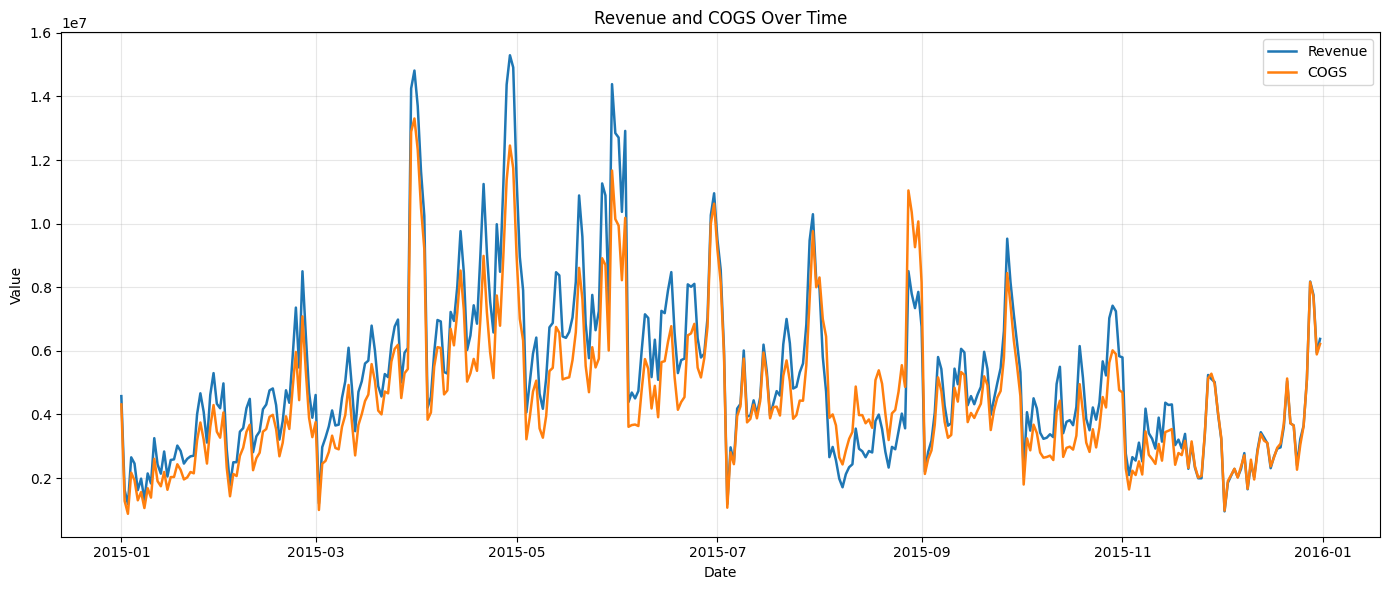

In [5]:
from src.data import load_sales
df_sales = load_sales(data_root=DATA_ROOT, parse_dates=True)
# Display 2015
plot_df = df_sales[(df_sales["Date"].dt.year == 2015)][["Date", "Revenue", "COGS"]].copy()
plot_df = plot_df.sort_values("Date")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_df["Date"], plot_df["Revenue"], label="Revenue", linewidth=1.8)
ax.plot(plot_df["Date"], plot_df["COGS"], label="COGS", linewidth=1.8)

ax.set_title("Revenue and COGS Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

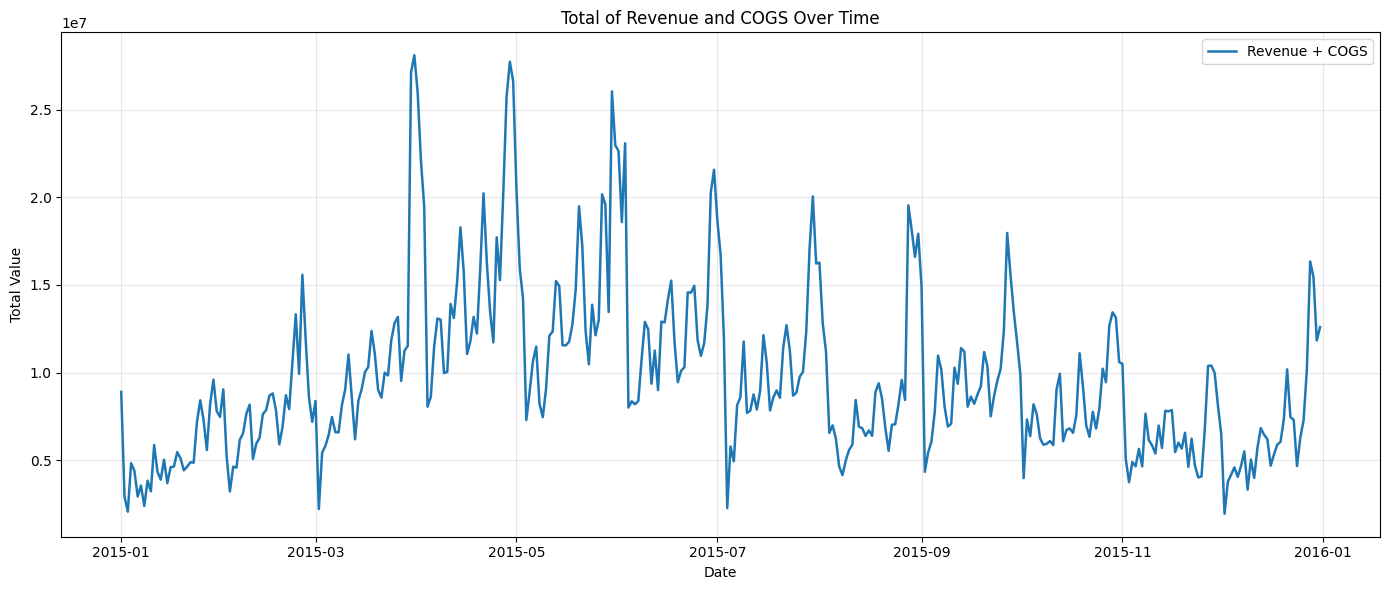

In [7]:
# plot sum of revenue and cogs 
plot_df["Total"] = plot_df["Revenue"] + plot_df["COGS"]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_df["Date"], plot_df["Total"], label="Revenue + COGS", linewidth=1.8)
ax.set_title("Total of Revenue and COGS Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Total Value")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

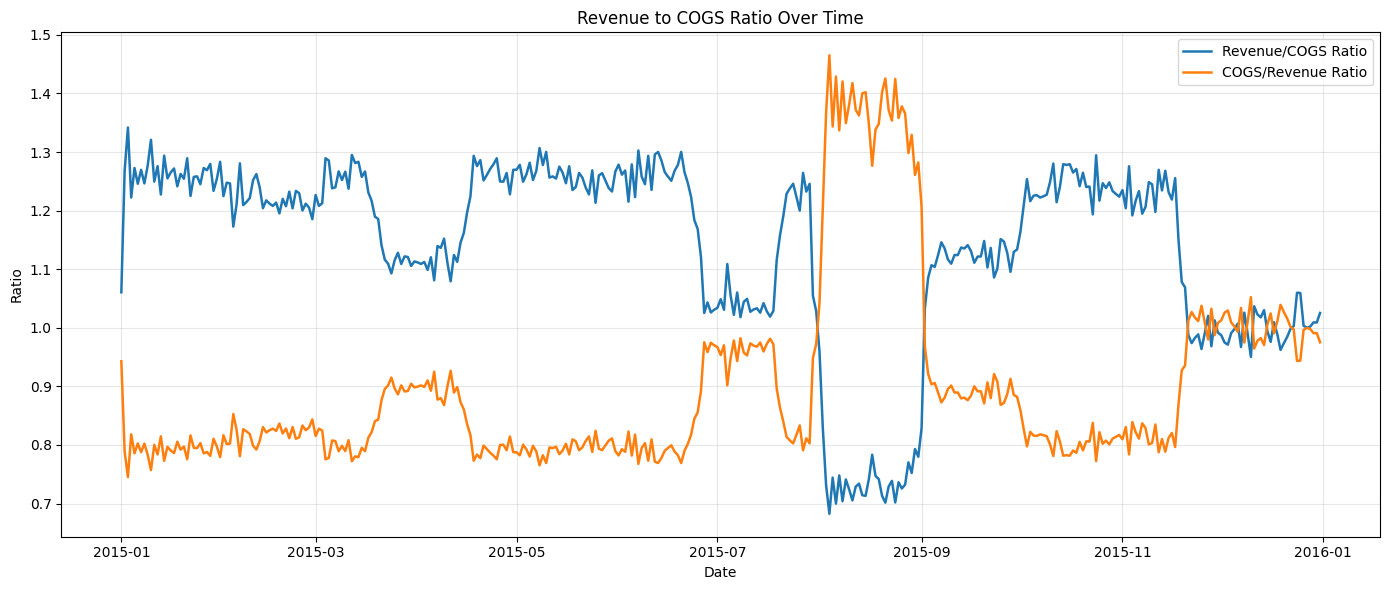

In [6]:
# plot cogs / revenue ratio and revenue / cogs ratio for 2015
plot_df["Ratio"] = plot_df["Revenue"] / plot_df["COGS"]
plot_df["InvRatio"] = plot_df["COGS"] / plot_df["Revenue"]
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_df["Date"], plot_df["Ratio"], label="Revenue/COGS Ratio", linewidth=1.8)
ax.plot(plot_df["Date"], plot_df["InvRatio"], label="COGS/Revenue Ratio", linewidth=1.8)
ax.set_title("Revenue to COGS Ratio Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Ratio")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

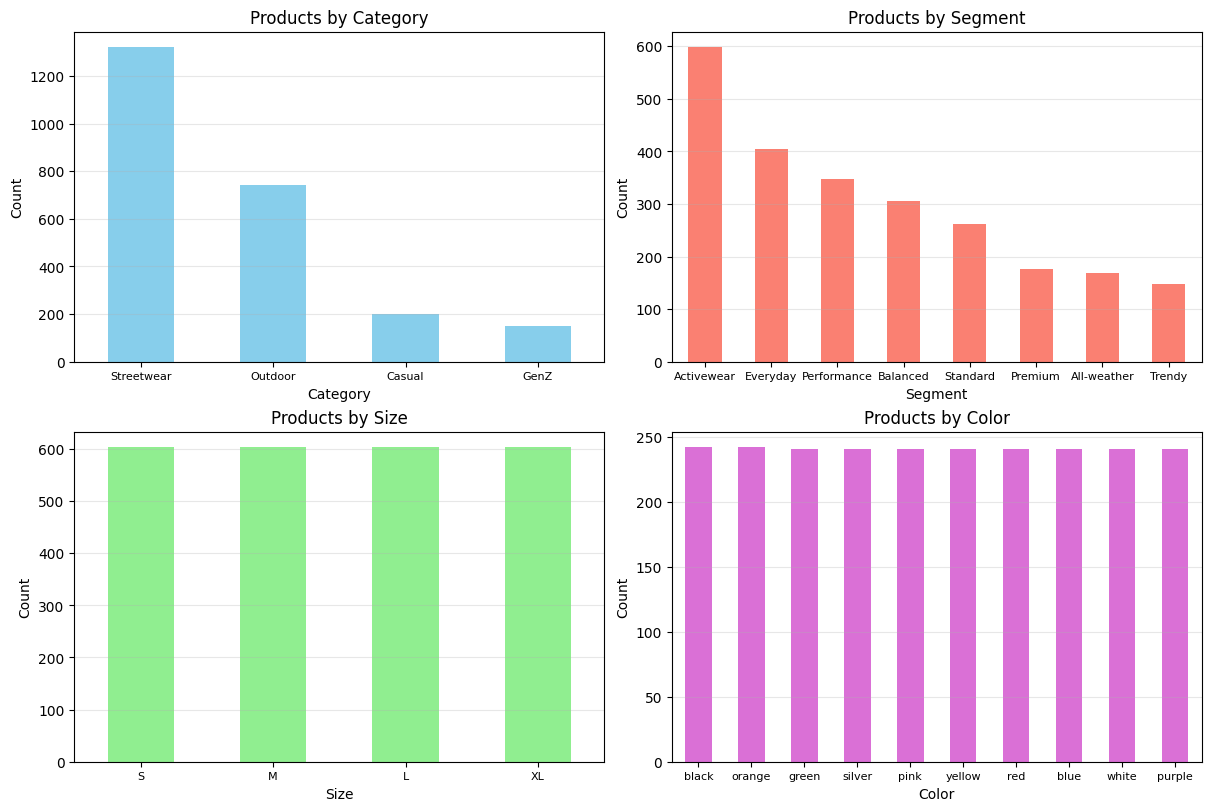

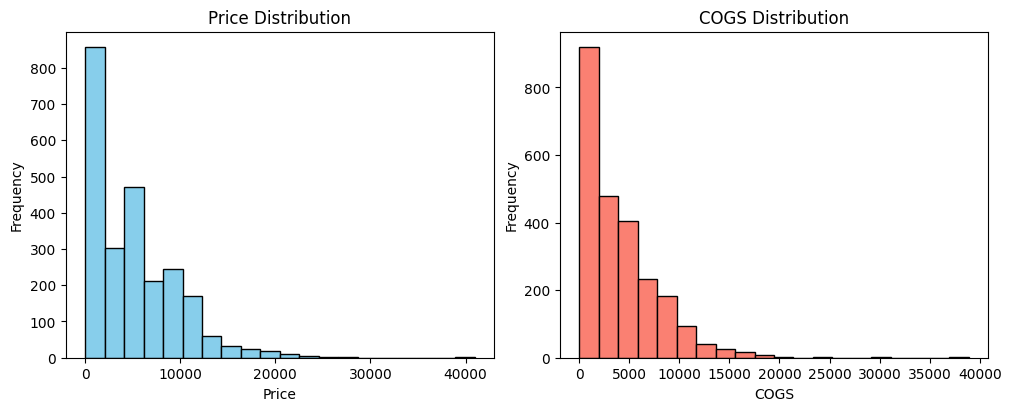

In [5]:
from src.data import load_products
df_products = load_products(data_root=DATA_ROOT)

# Compact multi-panel count plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

category_counts = df_products["category"].value_counts()
segment_counts = df_products["segment"].value_counts()
size_counts = df_products["size"].value_counts()
color_counts = df_products["color"].value_counts()

category_counts.plot(kind="bar", color="skyblue", ax=axes[0, 0])
axes[0, 0].set_title("Products by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(axis="y", alpha=0.3)
axes[0, 0].tick_params(axis="x", labelrotation=0, labelsize=8)

segment_counts.plot(kind="bar", color="salmon", ax=axes[0, 1])
axes[0, 1].set_title("Products by Segment")
axes[0, 1].set_xlabel("Segment")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(axis="y", alpha=0.3)
axes[0, 1].tick_params(axis="x", labelrotation=0, labelsize=8)

size_counts.plot(kind="bar", color="lightgreen", ax=axes[1, 0])
axes[1, 0].set_title("Products by Size")
axes[1, 0].set_xlabel("Size")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(axis="y", alpha=0.3)
axes[1, 0].tick_params(axis="x", labelrotation=0, labelsize=8)

color_counts.plot(kind="bar", color="orchid", ax=axes[1, 1])
axes[1, 1].set_title("Products by Color")
axes[1, 1].set_xlabel("Color")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].tick_params(axis="x", labelrotation=0, labelsize=8)

plt.show()

# Compact price and cogs distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].hist(df_products["price"], bins=20, color="skyblue", edgecolor="black")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_products["cogs"], bins=20, color="salmon", edgecolor="black")
axes[1].set_title("COGS Distribution")
axes[1].set_xlabel("COGS")
axes[1].set_ylabel("Frequency")

plt.show()

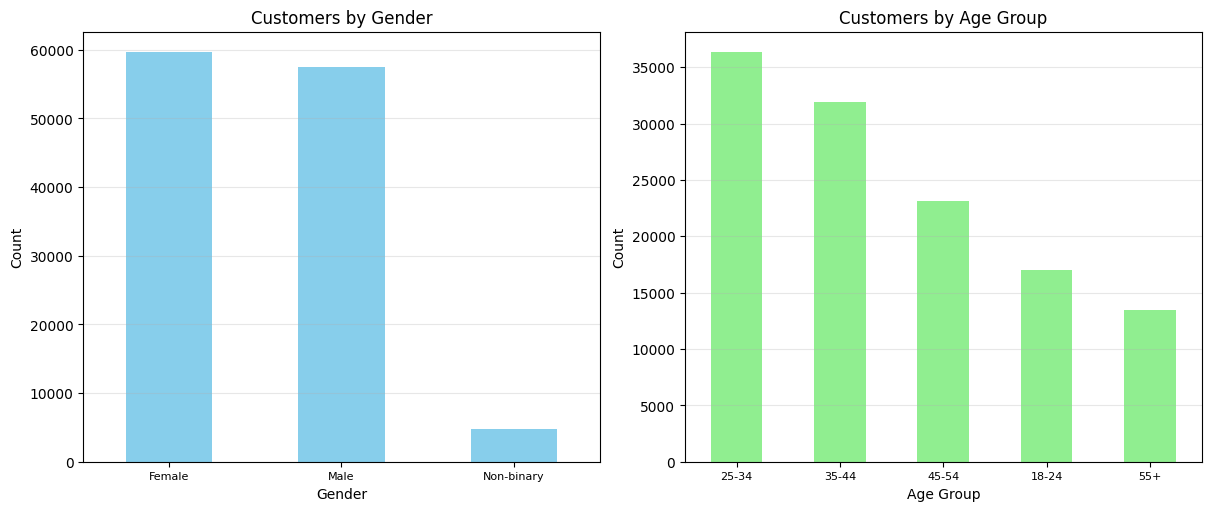

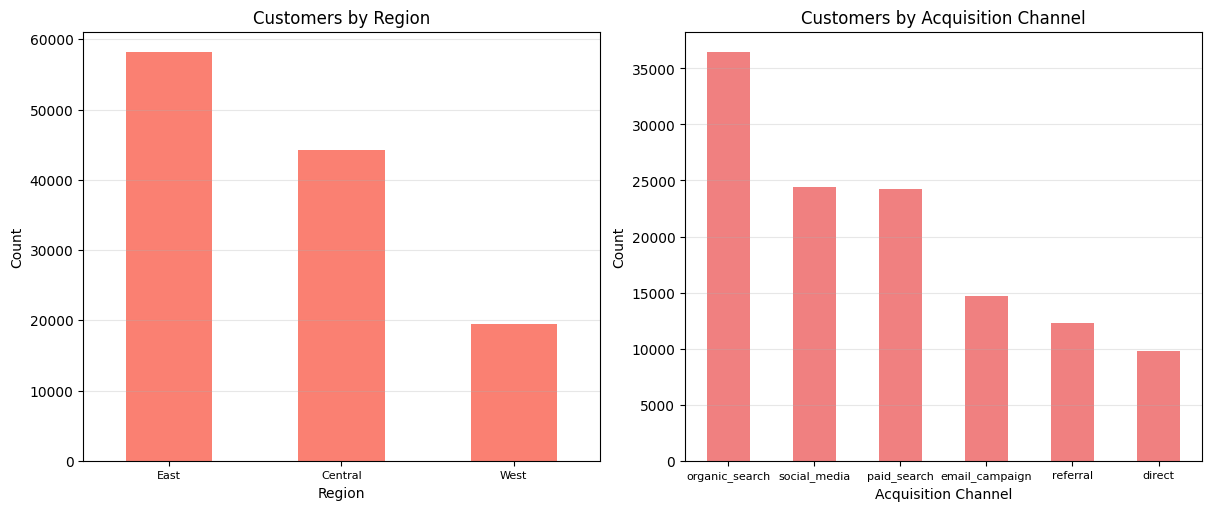

In [24]:
from src.data import load_customers
import pandas as pd

# city, signup_date, gender, age_group, acquisition_channel
df_customers = load_customers(data_root=DATA_ROOT)

# Add region if not present by joining geography on zip
if "region" not in df_customers.columns:
    geography_path = DATA_ROOT / "master" / "geography.csv"
    df_geo = pd.read_csv(geography_path)
    df_geo["zip"] = df_geo["zip"].astype(str)
    df_customers["zip"] = df_customers["zip"].astype(str)
    df_customers = df_customers.merge(
        df_geo[["zip", "region"]].drop_duplicates(),
        on="zip",
        how="left",
    )

# Compact multi-panel count plots for customers
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

gender_counts = df_customers["gender"].fillna("Unknown").value_counts()
gender_counts.plot(kind="bar", color="skyblue", ax=axes[0])
axes[0].set_title("Customers by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", labelrotation=0, labelsize=8)

age_group_counts = df_customers["age_group"].fillna("Unknown").value_counts()
age_group_counts.plot(kind="bar", color="lightgreen", ax=axes[1])
axes[1].set_title("Customers by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", labelrotation=0, labelsize=8)

plt.show()

# Region and acquisition channel distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
region_counts = df_customers["region"].fillna("Unknown").value_counts()
region_counts.plot(kind="bar", color="salmon", ax=axes[0])
axes[0].set_title("Customers by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", labelrotation=0, labelsize=8)

acquisition_counts = df_customers["acquisition_channel"].fillna("Unknown").value_counts()
acquisition_counts.plot(kind="bar", color="lightcoral", ax=axes[1])
axes[1].set_title("Customers by Acquisition Channel")
axes[1].set_xlabel("Acquisition Channel")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", labelrotation=0, labelsize=8)

plt.show()


In [ ]:
from src.data import load_order_items


df_order_items = load_order_items(data_root=DATA_ROOT)
total_quantity_items = df_order_items.groupby("product_id")["quantity"].sum().reset_index(name="total_quantity")
print(total_quantity_items.head(100))

    product_id  total_quantity
0            1               8
1            3            2584
2            4             735
3            5               1
4            7              95
..         ...             ...
95         190             240
96         191              41
97         193             260
98         195             107
99         196             102

[100 rows x 2 columns]
